# Step 3: Exploratory Data Analysis
**INT 396 — Unsupervised Learning | Social Media Topic Discovery for Disaster Response**

Tweet length distributions, top hashtags, label breakdowns, and CrisisBench event volume analysis.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = str(PROJECT_ROOT)

# Load cleaned datasets
humaid = pd.read_parquet(f"{PROJECT_ROOT}/data/processed/humaid_clean.parquet")
cb = pd.read_parquet(f"{PROJECT_ROOT}/data/processed/crisisbench_clean.parquet")
print(f"HumAID: {len(humaid):,} rows")
print(f"CrisisBench: {len(cb):,} rows")

HumAID: 76,477 rows
CrisisBench: 80,982 rows


## 3.1 Tweet Length Distributions

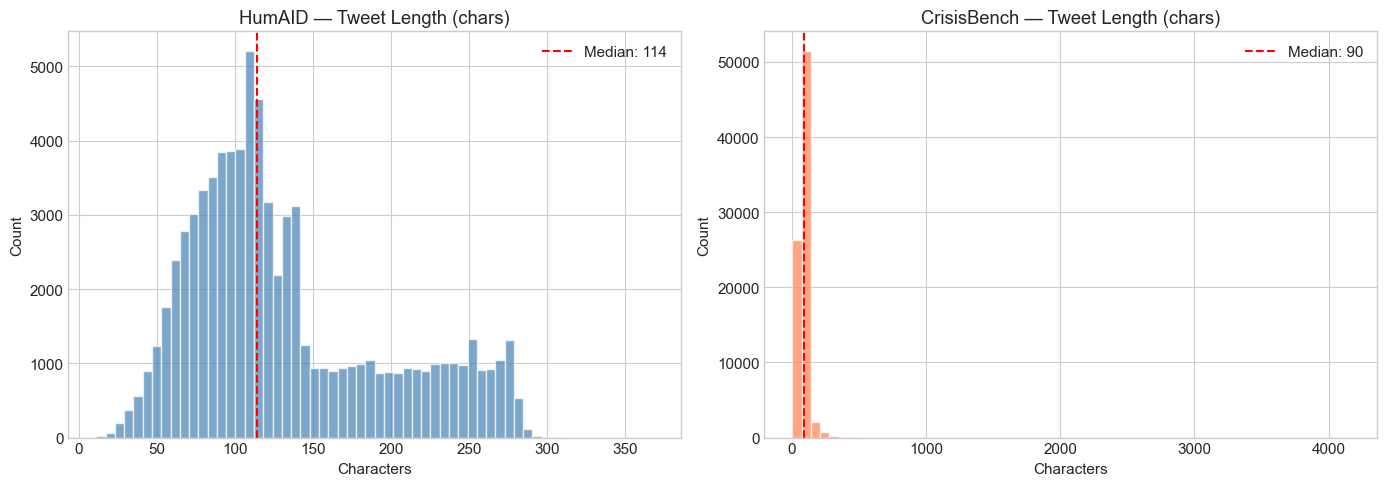

HumAID stats:
       text_len  word_count
count   76477.0     76477.0
mean      132.1        21.4
std        63.1        10.7
min        11.0         3.0
25%        87.0        14.0
50%       114.0        19.0
75%       168.0        27.0
max       368.0        61.0

CrisisBench stats:
       text_len  word_count
count   80982.0     80982.0
mean       92.0        15.1
std        46.5         7.8
min         4.0         1.0
25%        66.0        11.0
50%        90.0        14.0
75%       113.0        19.0
max      4153.0       641.0


In [2]:
humaid["text_len"] = humaid["text_clean"].str.len()
humaid["word_count"] = humaid["text_clean"].str.split().str.len()
cb["text_len"] = cb["text_clean"].str.len()
cb["word_count"] = cb["text_clean"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(humaid["text_len"], bins=60, alpha=0.7, color="steelblue", edgecolor="white")
axes[0].axvline(humaid["text_len"].median(), color="red", linestyle="--", label=f"Median: {humaid['text_len'].median():.0f}")
axes[0].set_title("HumAID — Tweet Length (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(cb["text_len"], bins=60, alpha=0.7, color="coral", edgecolor="white")
axes[1].axvline(cb["text_len"].median(), color="red", linestyle="--", label=f"Median: {cb['text_len'].median():.0f}")
axes[1].set_title("CrisisBench — Tweet Length (chars)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/eda_tweet_length.png", dpi=150, bbox_inches="tight")
plt.show()

print("HumAID stats:")
print(humaid[["text_len", "word_count"]].describe().round(1))
print("\nCrisisBench stats:")
print(cb[["text_len", "word_count"]].describe().round(1))

## 3.2 Label Distributions

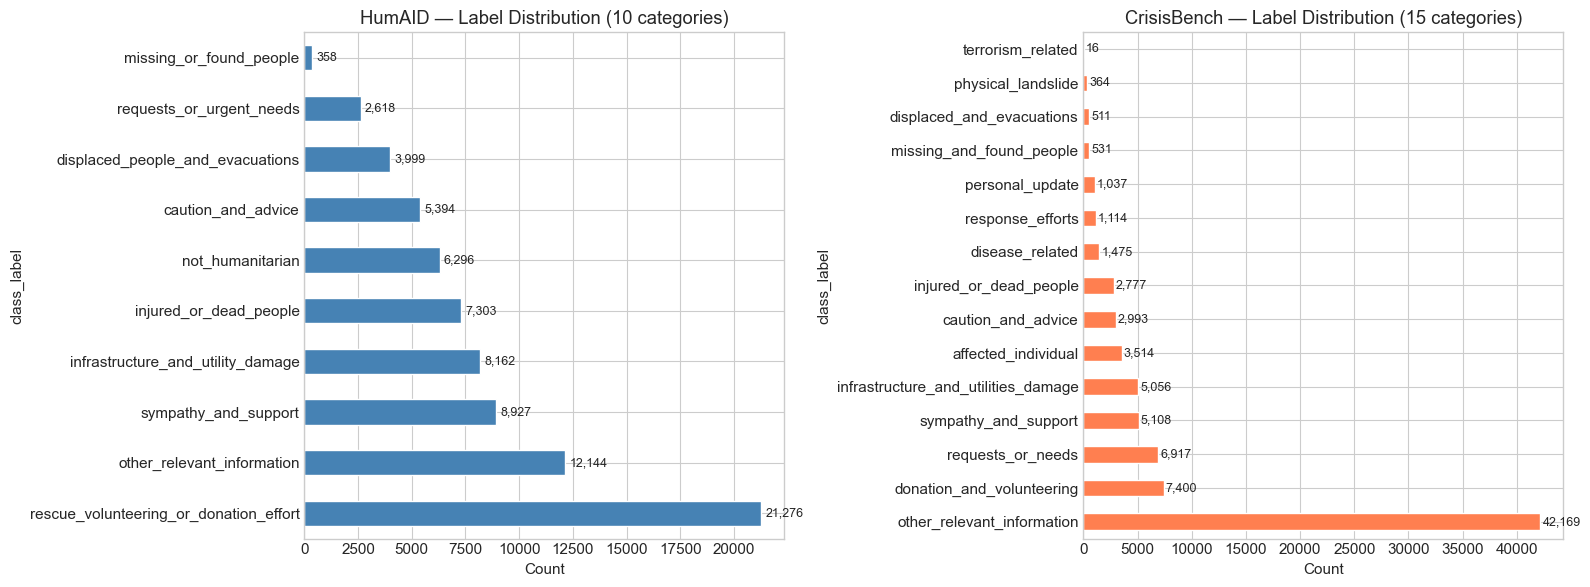

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HumAID labels
humaid_labels = humaid["class_label"].value_counts()
humaid_labels.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("HumAID — Label Distribution (10 categories)")
axes[0].set_xlabel("Count")
for i, v in enumerate(humaid_labels.values):
    axes[0].text(v + 200, i, f"{v:,}", va="center", fontsize=9)

# CrisisBench labels
cb_labels = cb["class_label"].value_counts()
cb_labels.plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("CrisisBench — Label Distribution (15 categories)")
axes[1].set_xlabel("Count")
for i, v in enumerate(cb_labels.values):
    axes[1].text(v + 200, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/eda_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 Top Hashtags (from original text before cleaning)

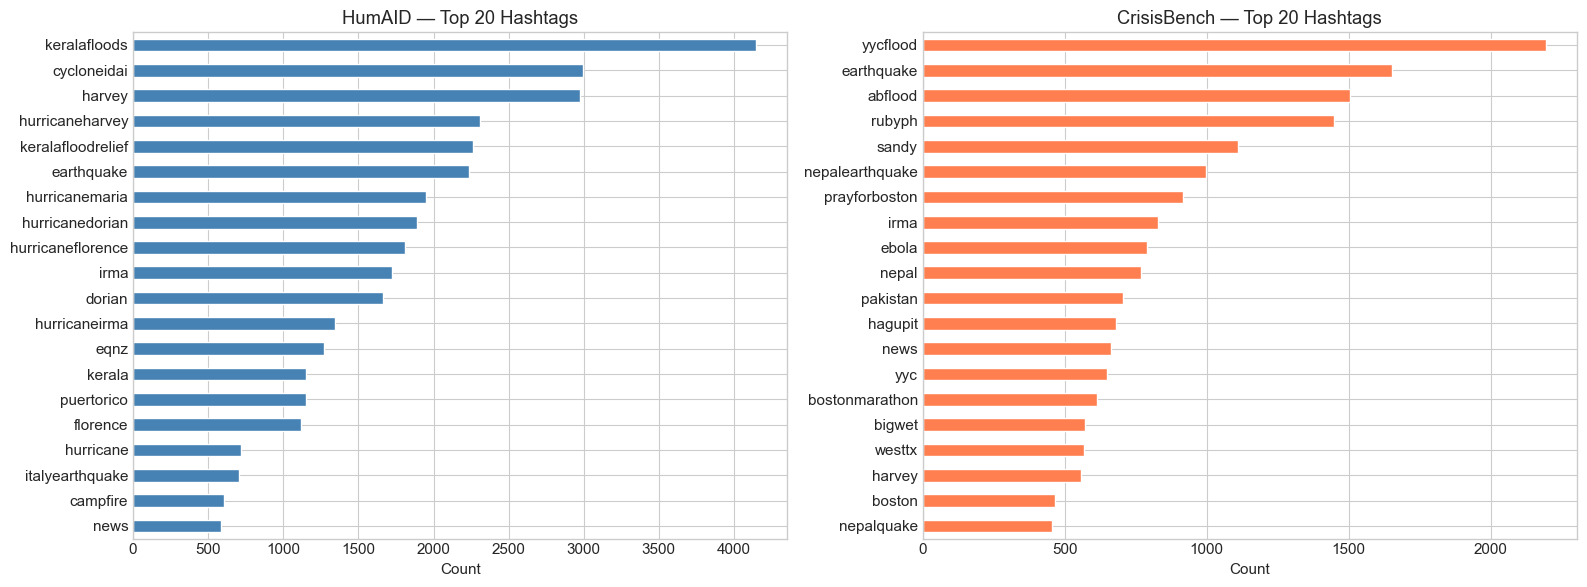

Unique hashtags — HumAID: 16,601, CrisisBench: 12,343


In [4]:
def extract_hashtags(text_series):
    """Extract hashtags from original (uncleaned) text."""
    hashtags = []
    for text in text_series.dropna():
        hashtags.extend(re.findall(r'#(\w+)', text.lower()))
    return Counter(hashtags)

# HumAID hashtags from original text
humaid_tags = extract_hashtags(humaid["tweet_text"])
top_humaid = pd.Series(dict(humaid_tags.most_common(20)))

# CrisisBench hashtags from original text
cb_tags = extract_hashtags(cb["text"])
top_cb = pd.Series(dict(cb_tags.most_common(20)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_humaid.sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("HumAID — Top 20 Hashtags")
axes[0].set_xlabel("Count")

top_cb.sort_values().plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("CrisisBench — Top 20 Hashtags")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/eda_top_hashtags.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Unique hashtags — HumAID: {len(humaid_tags):,}, CrisisBench: {len(cb_tags):,}")

## 3.4 CrisisBench Event Volume Analysis

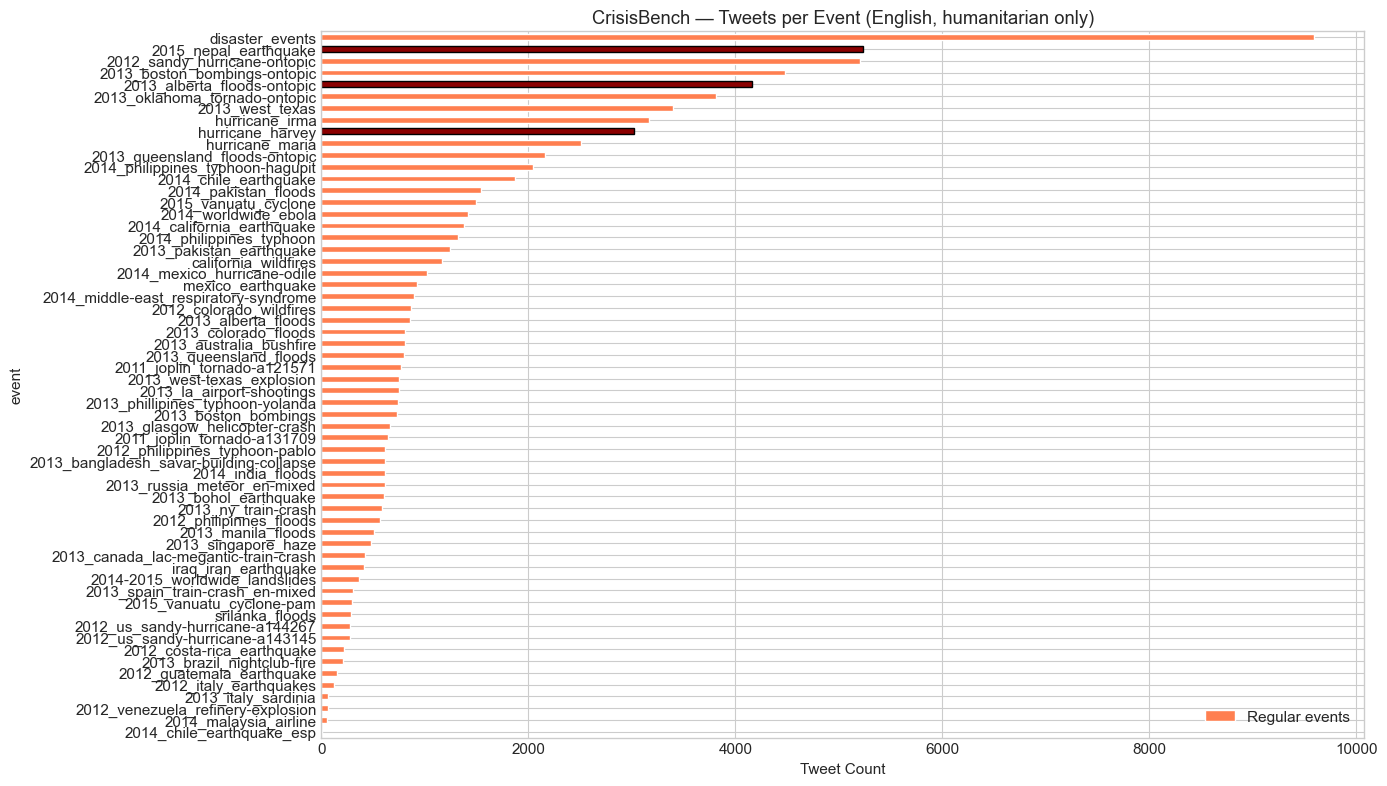

Total events: 60

Pre-selected validation events:
  2015_nepal_earthquake: 5,236 tweets, 11 label categories
  hurricane_harvey: 3,022 tweets, 6 label categories
  2013_alberta_floods-ontopic: 4,159 tweets, 1 label categories


In [5]:
# Event volume bar chart
event_counts = cb["event"].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
event_counts.sort_values().plot(kind="barh", ax=ax, color="coral", edgecolor="white")
ax.set_title("CrisisBench — Tweets per Event (English, humanitarian only)")
ax.set_xlabel("Tweet Count")

# Highlight the 3 pre-selected validation events
target_events = ["2015_nepal_earthquake", "hurricane_harvey", "2013_alberta_floods-ontopic"]
yticks = list(event_counts.sort_values().index)
for event in target_events:
    if event in yticks:
        idx = yticks.index(event)
        ax.get_children()[idx].set_color("darkred")
        ax.get_children()[idx].set_edgecolor("black")

ax.legend(["Regular events", "Pre-selected validation events"], loc="lower right")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/eda_crisisbench_events.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total events: {cb['event'].nunique()}")
print(f"\nPre-selected validation events:")
for e in target_events:
    n = len(cb[cb['event'] == e])
    labels = cb[cb['event'] == e]['class_label'].nunique()
    print(f"  {e}: {n:,} tweets, {labels} label categories")

## 3.5 Label Distribution per Validation Event

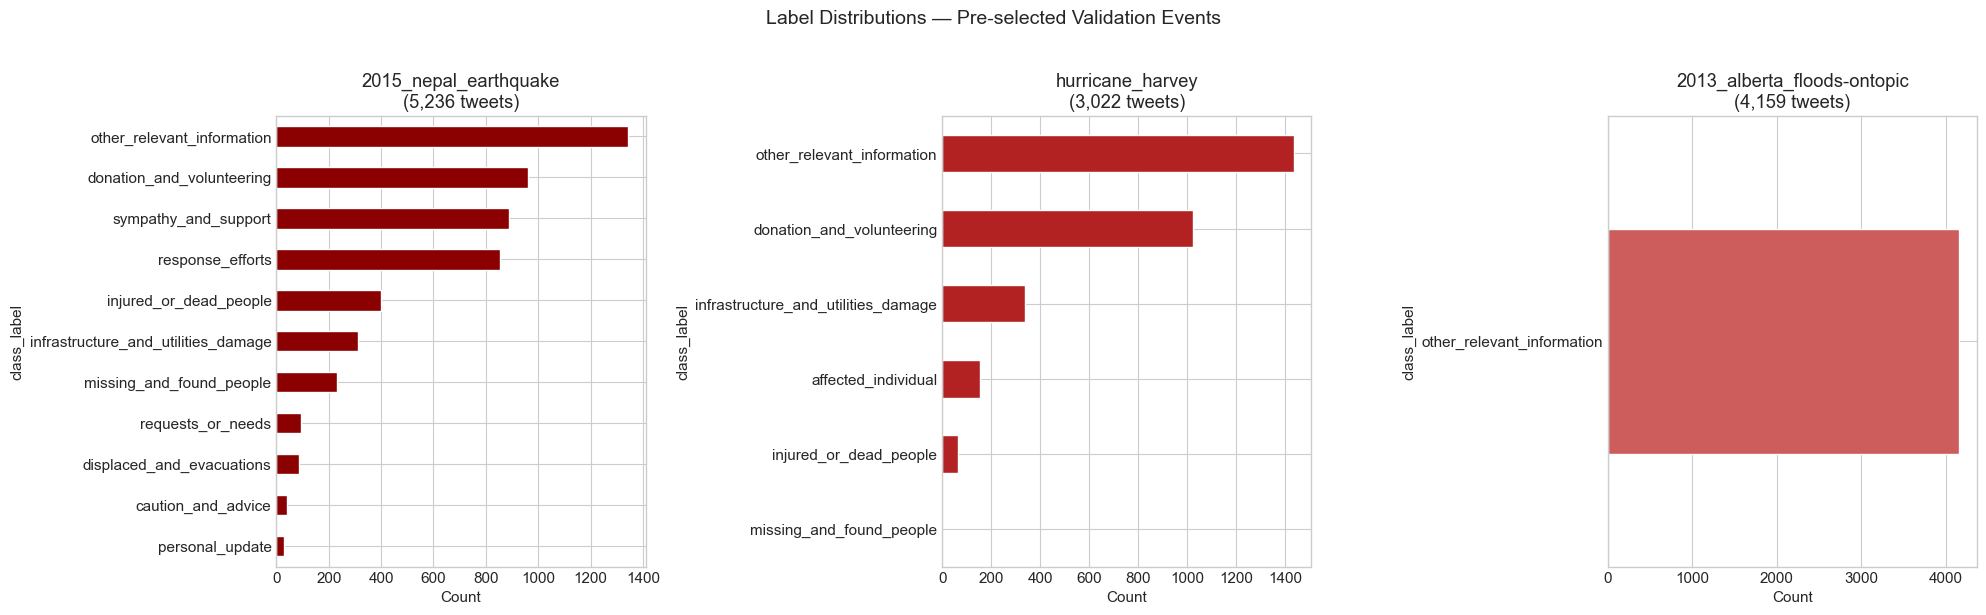

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ["#8B0000", "#B22222", "#CD5C5C"]

for i, event in enumerate(target_events):
    event_df = cb[cb["event"] == event]
    labels = event_df["class_label"].value_counts()
    labels.sort_values().plot(kind="barh", ax=axes[i], color=colors[i], edgecolor="white")
    axes[i].set_title(f"{event}\n({len(event_df):,} tweets)")
    axes[i].set_xlabel("Count")

plt.suptitle("Label Distributions — Pre-selected Validation Events", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/eda_validation_events_labels.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.6 Summary Statistics

In [7]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nHumAID (primary):")
print(f"  Rows: {len(humaid):,}")
print(f"  Labels: {humaid['class_label'].nunique()}")
print(f"  Avg tweet length: {humaid['text_len'].mean():.0f} chars / {humaid['word_count'].mean():.0f} words")
print(f"  Unique hashtags: {len(humaid_tags):,}")

print(f"\nCrisisBench (validation, English + humanitarian):")
print(f"  Rows: {len(cb):,}")
print(f"  Labels: {cb['class_label'].nunique()}")
print(f"  Events: {cb['event'].nunique()}")
print(f"  Avg tweet length: {cb['text_len'].mean():.0f} chars / {cb['word_count'].mean():.0f} words")
print(f"  Unique hashtags: {len(cb_tags):,}")

print(f"\nValidation events:")
for e in target_events:
    n = len(cb[cb['event'] == e])
    print(f"  {e}: {n:,} tweets")

print(f"\nNext step: Run 04_feature_extraction.ipynb to generate SBERT embeddings and TF-IDF vectors.")

DATASET SUMMARY

HumAID (primary):
  Rows: 76,477
  Labels: 10
  Avg tweet length: 132 chars / 21 words
  Unique hashtags: 16,601

CrisisBench (validation, English + humanitarian):
  Rows: 80,982
  Labels: 15
  Events: 60
  Avg tweet length: 92 chars / 15 words
  Unique hashtags: 12,343

Validation events:
  2015_nepal_earthquake: 5,236 tweets
  hurricane_harvey: 3,022 tweets
  2013_alberta_floods-ontopic: 4,159 tweets

Next step: Run 04_feature_extraction.ipynb to generate SBERT embeddings and TF-IDF vectors.
